## **Figure-S8**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
def loadLibraryFragmentIonIntensities(fIn, compression=None, charge='PrecursorCharge', seq='ModifiedPeptideSequence', fragmentType='FragmentType', fragmentNumber='FragmentSeriesNumber', fragmentLoss='FragmentLossType', framentCharge='FragmentCharge', libIntens='LibraryIntensity'):
    print(fIn)
    if fragmentLoss is not None:
        usecols = [charge, seq, fragmentType, fragmentNumber, fragmentLoss, framentCharge, libIntens]
    else:
        usecols = [charge, seq, fragmentType, fragmentNumber, framentCharge, libIntens]

        
    lib = pd.read_csv(fIn, sep='\t', compression=compression, usecols=usecols)
    lib['Precursor'] = lib[seq] + lib[charge].astype(str)

    # different schema depending on if fragmentLoss column is present
    if fragmentLoss is not None:
        lib['FragmentLossType'] = lib['FragmentLossType'].fillna("unknown")
        lib['Fragment.Info'] = lib['Precursor'] + lib[fragmentType] + lib[fragmentNumber].astype(str) + '-' + lib[fragmentLoss] + '^' + lib[framentCharge].astype(str)
    else: 
        lib['Fragment.Info'] = lib['Precursor'] + lib[fragmentType] + lib[fragmentNumber].astype(str) + '^' + lib[framentCharge].astype(str)

    lib = lib.rename(columns={libIntens: 'LibraryIntensity'})
    return lib[['Fragment.Info', 'LibraryIntensity']]
    

def load_diann_frag(fIn, fragInfo='Fragment.Info', fragQuant='Fragment.Quant.Raw', precursor='Precursor.Id', q='Q.Value', proteinQ='Protein.Q.Value'):
    print(fIn)
    df = pd.read_csv(fIn, sep='\t', usecols=[fragInfo, fragQuant, precursor, q, proteinQ])
    # filter to fdr = 1%
    df = df[(df[q] < 0.01) & (df[proteinQ] < 0.01)].copy()
    
    # Split both columns and remove /number patterns
    split_info = df[fragInfo].str.slice(start=0, stop=-1).str.split(";", expand=False)
    split_info = split_info.apply(lambda x: [item.rsplit('/', 1)[0] for item in x])
    split_quant = df[fragQuant].str.slice(start=0, stop=-1).str.split(";", expand=False)
    
    # Create a temporary dataframe with split columns, then explode
    df_temp = df.copy()
    df_temp['_temp_info'] = split_info
    df_temp['_temp_quant'] = split_quant
    
    # Explode into long format
    df_exploded = (
        df_temp
        .explode(['_temp_info', '_temp_quant'])
        .drop(columns=[fragInfo, fragQuant])
        .rename(columns={
            '_temp_info': fragInfo,
            '_temp_quant': fragQuant
        })
        .reset_index(drop=True)
    )
    
    # Concatenate precursor ID with fragment info
    df_exploded[fragInfo] = df_exploded[precursor] + df_exploded[fragInfo]
    df_exploded[fragQuant] = df_exploded[fragQuant].astype(float)
    
    return df_exploded.dropna()

---

---

In [4]:
names = dict(exp='Experimental',
             silico='in-silico',
             bruker='timsTOF, 2024',
             panhuman='PanHuman, 2014')
condition = dict(orig='Initial', refined='Reconstructed', tl='Transfer-Learn')

#### **Load Data**

In [5]:
diann = { n:defaultdict(dict) for n in names.values() }

In [6]:
# Bruker data
diann[names['bruker']][condition['orig']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['refined']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['bruker']][condition['tl']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

# Silico data
diann[names['silico']][condition['orig']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['refined']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['silico']][condition['tl']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

# exp data
diann[names['exp']][condition['orig']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['exp']][condition['refined']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)
diann[names['exp']][condition['tl']] = getPrecursorDf_Characteristics_Diann("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv", infer_schema_length=1000)

# Panhuman data
diann[names['panhuman']][condition['orig']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['refined']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann[names['panhuman']][condition['tl']] = getPrecursorDf_Characteristics_Diann("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DI

In [7]:
diann_frag = { n:defaultdict(dict) for n in names.values() }
# Bruker data
diann_frag[names['bruker']][condition['orig']] = load_diann_frag("../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['bruker']][condition['refined']] = load_diann_frag("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['bruker']][condition['tl']] = load_diann_frag("../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

# Silico data
diann_frag[names['silico']][condition['orig']] = load_diann_frag("../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['silico']][condition['refined']] = load_diann_frag("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['silico']][condition['tl']] = load_diann_frag("../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

# exp data
diann_frag[names['exp']][condition['orig']] = load_diann_frag("../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['exp']][condition['refined']] = load_diann_frag("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['exp']][condition['tl']] = load_diann_frag("../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

# Panhuman data
diann_frag[names['panhuman']][condition['orig']] = load_diann_frag("../../results/K562-PanHuman-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['panhuman']][condition['refined']] = load_diann_frag("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")
diann_frag[names['panhuman']][condition['tl']] = load_diann_frag("../../results/K562-PanHuman-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv")

../../results/K562-Bruker-Library-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Bruker-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-PeptDeep-NoMods-Lib-Refined-GPF-Analysis/diann_tl/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Exp-Lib-Analysis/diann/Rost_DIApy3_SP2um_90min_250ngK562_100nL_1_Slot1-5_1_1330_6-28-2021/report.tsv
../../results/K562-Exp-Lib-Refined-GPF-Analysis/diann/Rost_DI

In [8]:
libs = { n:defaultdict(dict) for n in names.values() }
libs[names['bruker']][condition['orig']] = loadLibraryFragmentIonIntensities("../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv")
libs[names['bruker']][condition['refined']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-Bruker-Lib-With-GPF/2025-06-10-diann-bruker-gpf-refined.tsv", fragmentLoss=None)
libs[names['bruker']][condition['tl']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-Bruker-Lib-With-GPF/diann_transfer_learn/2025-06-10-Bruker-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv", fragmentLoss=None, libIntens='RelativeIntensity', framentCharge='ProductCharge')

libs[names['silico']][condition['orig']] = loadLibraryFragmentIonIntensities("../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv", fragmentLoss=None, framentCharge='ProductCharge', libIntens='RelativeIntensity')
libs[names['silico']][condition['refined']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-PeptDeep-NoMods-With-GPF/2025-06-18-peptdeep-nomods-gpf-refined-diann.tsv", fragmentLoss=None)
libs[names['silico']][condition['tl']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-PeptDeep-NoMods-With-GPF/diann_tl/2025-06-21-PeptDeepNoMods-TL-On-GPF-DIANN_fix_mods_filtered.tsv", fragmentLoss=None, libIntens='RelativeIntensity', framentCharge='ProductCharge')

libs[names['exp']][condition['orig']] = loadLibraryFragmentIonIntensities("../../results/K562-Library-Generation/library.tsv")
libs[names['exp']][condition['refined']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-Exp-Lib-With-GPF/2025-03-06-diann-gpf-lib.tsv", fragmentLoss=None)
libs[names['exp']][condition['tl']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-Exp-Lib-With-GPF/diann_transfer_learn/2025-06-11-ExpLib-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv", fragmentLoss=None, libIntens='RelativeIntensity', framentCharge='ProductCharge')

../../data/BrukerLibrary/_ip2_ip2_data_paser_spectral_library__Bruker_Human.tsv
../../results/K562-Refine-Bruker-Lib-With-GPF/2025-06-10-diann-bruker-gpf-refined.tsv
../../results/K562-Refine-Bruker-Lib-With-GPF/diann_transfer_learn/2025-06-10-Bruker-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv
../../results/PeptDeep-NoMods-In-Silico-Library-Generation/2025-06-10-in-silico-lib-no-mods_fix_mods_filtered.tsv
../../results/K562-Refine-PeptDeep-NoMods-With-GPF/2025-06-18-peptdeep-nomods-gpf-refined-diann.tsv
../../results/K562-Refine-PeptDeep-NoMods-With-GPF/diann_tl/2025-06-21-PeptDeepNoMods-TL-On-GPF-DIANN_fix_mods_filtered.tsv
../../results/K562-Library-Generation/library.tsv
../../results/K562-Refine-Exp-Lib-With-GPF/2025-03-06-diann-gpf-lib.tsv
../../results/K562-Refine-Exp-Lib-With-GPF/diann_transfer_learn/2025-06-11-ExpLib-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv


In [9]:
libs[names['panhuman']][condition['orig']] = loadLibraryFragmentIonIntensities("../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv", fragmentLoss=None, framentCharge='ProductCharge')
libs[names['panhuman']][condition['refined']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-PanHuman-Lib-With-GPF/2025-06-10-diann-panhuman-gpf-refined.tsv", fragmentLoss=None)
#libs[names['panhuman']][condition['refined']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-PanHuman-Lib-Wih-GPF/", fragmentLoss=None)

libs[names['panhuman']][condition['tl']] = loadLibraryFragmentIonIntensities("../../results/K562-Refine-PanHuman-Lib-With-GPF/diann_transfer_learn/2025-06-10-PanHuman-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv", fragmentLoss=None, libIntens='RelativeIntensity', framentCharge='ProductCharge')

../../results/PanHuman-Library-Creation/phl004_s32_imAppended_fixed_diann.tsv
../../results/K562-Refine-PanHuman-Lib-With-GPF/2025-06-10-diann-panhuman-gpf-refined.tsv
../../results/K562-Refine-PanHuman-Lib-With-GPF/diann_transfer_learn/2025-06-10-PanHuman-Lib-Transfer-Learn-GPF-Models-DIANN_fix_mods.tsv


#### **Compute Fragment Ion Intensities**

In [10]:
diann_frag_computed = { n:defaultdict(dict) for n in names.values() }

for l in names.values():
    for c in condition.values():
        print(l, c)
        if c == condition['tl']:
            norm_factor = 1
        elif l == names['silico'] and c == condition['orig']:
            norm_factor = 1
        else:
            norm_factor = 10000
        diann_frag_computed[l][c] = compute_frag_intensity_residuals_diann(libs[l][c], diann_frag[l][c], norm_factor=norm_factor)
    

Experimental Initial
Experimental Reconstructed
Experimental Transfer-Learn
in-silico Initial
in-silico Reconstructed
in-silico Transfer-Learn
timsTOF, 2024 Initial
timsTOF, 2024 Reconstructed
timsTOF, 2024 Transfer-Learn
PanHuman, 2014 Initial
PanHuman, 2014 Reconstructed
PanHuman, 2014 Transfer-Learn


#### **DIA-NN Plots**

In [11]:
tmp = {}
for k, v in diann.items():
    tmp[k] = pd.concat(v).reset_index(names=['Condition', 'i']).drop(columns='i')
    
diann_df = pd.concat(tmp).reset_index(names=['Library', 'i']).drop(columns='i')
    

In [12]:
tmp = {}
for k, v in diann_frag_computed.items():
    tmp[k] = pd.concat(v).reset_index(names=['Condition', 'i']).drop(columns='i')
    
diann_frag_df = pd.concat(tmp).reset_index(names=['Library', 'i']).drop(columns='i')
    

In [13]:
def create_characteristics_boxplot(ax, data, y, ylabel, show_xticks, ylim=None, font_size_small=7, font_size_medium=11, font_size_large=11):
    sns.set_palette(["tab:blue", "tab:orange", "tab:grey"])
    sns.boxplot(data=data, x='Library', hue='Condition', y=y, showfliers=False, ax=ax, order=names.values(), legend=False)
    ax.set_ylabel(ylabel, fontsize=font_size_medium)
    ax.axhline(0, color='black')

    if not show_xticks:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Library", fontsize=font_size_medium)
        for l in ax.get_xticklabels():
            if l.get_text() == 'in-silico':
                l.set_fontstyle('italic')
    
    ax.tick_params(axis='both', which='major', labelsize=font_size_small)
    if ylim is not None:
        ax.set_ylim(ylim)


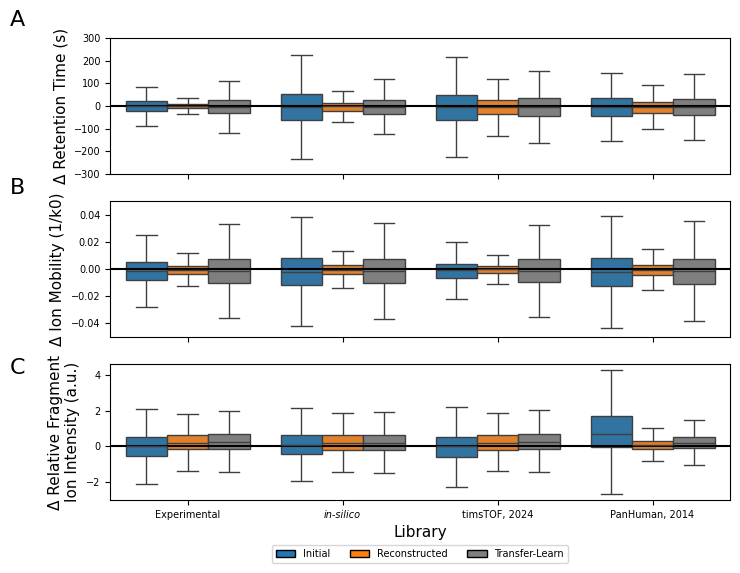

In [14]:
fig, (ax1,ax2,ax3) = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

create_characteristics_boxplot(ax1, diann_df, 'deltaRT', 'Δ Retention Time (s)', show_xticks=False, ylim=(-300, 300))

create_characteristics_boxplot(ax2, diann_df, 'deltaIM', 'Δ Ion Mobility (1/k0)', show_xticks=False, ylim=(-0.05, 0.05))

create_characteristics_boxplot(ax3, diann_frag_df, 'residual', 'Δ Relative Fragment\nIon Intensity (a.u.)', show_xticks=True)

# add legend for plots 
handles = [mpatches.Patch(facecolor=c, label=l, edgecolor='black') for c, l in zip(['tab:blue', 'tab:orange', 'tab:grey'], condition.values()) ]
ax3.legend(handles=handles, labels=condition.values(), ncols=3, loc='lower center', bbox_to_anchor=(0.5, -0.5), fontsize=7)

fig.text(0, 0.9, 'A', fontsize=16) 
fig.text(0, 0.62, 'B', fontsize=16)
fig.text(0, 0.32, 'C', fontsize=16) 

plt.savefig("Figure-S8.png", dpi=300, bbox_inches='tight')


In [15]:
diann_df[['Library', 'Condition', 'deltaRT']].groupby(['Library', 'Condition']).std()

deltaRT
Library        Condition                
Experimental   Initial         37.840643
               Reconstructed   17.186375
               Transfer-Learn  52.100143
PanHuman, 2014 Initial         65.420675
               Reconstructed   39.511968
               Transfer-Learn  63.006635
in-silico      Initial         97.397569
               Reconstructed   32.885200
               Transfer-Learn  55.171820
timsTOF, 2024  Initial         94.768916
               Reconstructed   50.890161
               Transfer-Learn  69.820924

In [16]:
(52.100/17.186 + 55.17/32.88 + 39.51/63.00 + 50.89/69.82) /4

1.5163685277597616